# Massive production of cancer synthetic RNA-Seq Gene Expression Samples - Trainer

This jupyter presents the code for training the WGAN-GP for producing synthetic samples related to a given cohort.

In [1]:
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
from torch import cuda
from torch.nn import Sequential,Linear,LeakyReLU, BatchNorm1d, Module,Tanh
from torch.utils.data import DataLoader,Dataset
from torch.autograd import Variable, grad
from torch.optim import Adam

from sklearn.preprocessing import StandardScaler


In [2]:
#Checking available devices
print(cuda.device_count())
print(cuda.get_device_name(0))

1
NVIDIA GeForce MX350


In [3]:
class Generator(Module):

    def __init__(self, z_length = 10, output_size: int = None) -> None:
        super(Generator,self).__init__()
        
        self.model = Sequential(
            Linear(z_length,32),
            LeakyReLU(0.2, inplace=True),

            Linear(32,64),
            BatchNorm1d(64,0.8),
            LeakyReLU(0.2, inplace=True),

            Linear(64,output_size),
            BatchNorm1d(output_size,0.8),
            Tanh()
        )

    def forward(self, z):
        return self.model(z)


In [4]:
class Discriminator(Module):

    def __init__(self, sample_size: int = None) -> None:
        super(Discriminator, self).__init__()
        
        self.model = Sequential(
            Linear(sample_size, 16),
            LeakyReLU(0.2, inplace= True),

            Linear(16,8),
            LeakyReLU(0.2, inplace=True),
            
            Linear(8,1),
        )

    def forward(self,x):
        return self.model(x)

## Loading data and creating dataloaders

In [5]:
class GeneExpDataset(Dataset):
    def __init__(self,dataset,label=1):
        super(GeneExpDataset,self).__init__()
        self.dataset=dataset
        self.label=label
    # Redefining .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefining .__getitem__()    
    def __getitem__(self,i):
        gene_data,label=self.dataset[i],self.label
        return gene_data,label

In [6]:
#Loading expression matrix
cohort = "THCA" #Options: BRCA, LUAD, PRAD, THCA
exp_matrix = pd.read_csv(f'../data/{cohort}/tumor_exp_matrix.csv',sep=';')

#Scaling matrix
exp_matrix = np.array(exp_matrix.values)
scaler_exp_matrix = StandardScaler().fit(exp_matrix)
scaled_exp_matrix = scaler_exp_matrix.transform(exp_matrix)

#Choose 75% of data for training
train_amount = int(len(exp_matrix)*0.75)

training_data = GeneExpDataset(scaled_exp_matrix[:train_amount])

training_dataloader = DataLoader(training_data, batch_size=128, shuffle=True)

In [7]:
#Preparing data for clipping, just in case of negative values
min_values = exp_matrix.min(axis=0)
max_values = exp_matrix.max(axis=0)

std_values = np.sqrt(scaler_exp_matrix.var_)

## Initialising model and defining hyperparameters

In [8]:
"""
Gradient Penalty to force the discriminator to follow the Lipzchits continuity.
"""
is_cuda = True if cuda.is_available() else False
Tensor = cuda.FloatTensor if is_cuda else torch.FloatTensor

def compute_gradient_penalty(D, real_samples, fake_samples):
    # Random weight term for interpolation between real and fake samples
    alpha = Tensor(np.random.random((real_samples.shape[0],1)))
    # Get random interpolation between real and fake samples
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)    
    d_interpolates = D(interpolates)
    fake = Variable(Tensor(real_samples.shape[0], 1).fill_(1.0), requires_grad=False)
    # Get gradient w.r.t. interpolates
    gradients = grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [9]:
# Initialize generator and discriminator
generator = Generator(output_size=exp_matrix.shape[1])
discriminator = Discriminator(sample_size=exp_matrix.shape[1])

if cuda:
    generator.cuda()
    discriminator.cuda()

In [10]:
# Optimizers
optimizer_G = Adam(generator.parameters(), lr=0.001, betas=(0.5, 0.990))
optimizer_D = Adam(discriminator.parameters(), lr=0.005, betas=(0.5, 0.990))

In [11]:
n_critic = 10 # Train the generator every n_critic steps
lambda_gp = 10 #Value used to add noise to the process.


d_losses = []
g_losses = []

def training_loop(dataloader):
    discriminator.train()
    generator.train()
    for i, (X,y) in enumerate(dataloader):
        #Train discriminator
        optimizer_D.zero_grad()

        #Configure input
        real_samples = Variable(X.type(Tensor))

        # Sample noise as generator input
        z = Variable(Tensor(np.random.normal(0, 1, (X.shape[0], 10))))

        #Generate a batch of images
        fake_samples = generator(z)

        #Real samples validity
        real_validity = discriminator(real_samples)

        #Fake samples validoty
        fake_validity = discriminator(fake_samples)

        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator,
                                                    real_samples.data,
                                                    fake_samples.data)
        
        #Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        d_loss.backward()
        optimizer_D.step()

        # OPTIMISING THE GENERATOR

        if i % n_critic == 0:
            optimizer_G.zero_grad()

            z = Variable(Tensor(np.random.normal(0, 1, (X.shape[0], 10))))

            #Generate a batch of images
            fake_samples = generator(z)
            fake_validity = discriminator(fake_samples)

            g_loss = -torch.mean(fake_validity)

            g_loss.backward()
            optimizer_G.step()

        print(
                f"[Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]"
            )
        
        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

            

## Train the WGAN-GP


Epoca: 0
[Batch 0/3] [D loss: 7.673229694366455] [G loss: 0.020045356824994087]
[Batch 1/3] [D loss: 7.275573253631592] [G loss: 0.020045356824994087]
[Batch 2/3] [D loss: 6.829473495483398] [G loss: 0.020045356824994087]

Epoca: 1
[Batch 0/3] [D loss: 6.366294860839844] [G loss: 0.044787127524614334]
[Batch 1/3] [D loss: 5.790410041809082] [G loss: 0.044787127524614334]
[Batch 2/3] [D loss: 5.157875061035156] [G loss: 0.044787127524614334]

Epoca: 2
[Batch 0/3] [D loss: 4.565110206604004] [G loss: 0.07279033213853836]
[Batch 1/3] [D loss: 3.8552298545837402] [G loss: 0.07279033213853836]
[Batch 2/3] [D loss: 3.162036657333374] [G loss: 0.07279033213853836]

Epoca: 3
[Batch 0/3] [D loss: 2.3378474712371826] [G loss: 0.10719168186187744]
[Batch 1/3] [D loss: 1.747809886932373] [G loss: 0.10719168186187744]
[Batch 2/3] [D loss: 1.269123911857605] [G loss: 0.10719168186187744]

Epoca: 4
[Batch 0/3] [D loss: 0.8807832598686218] [G loss: 0.13779768347740173]
[Batch 1/3] [D loss: 0.67622423

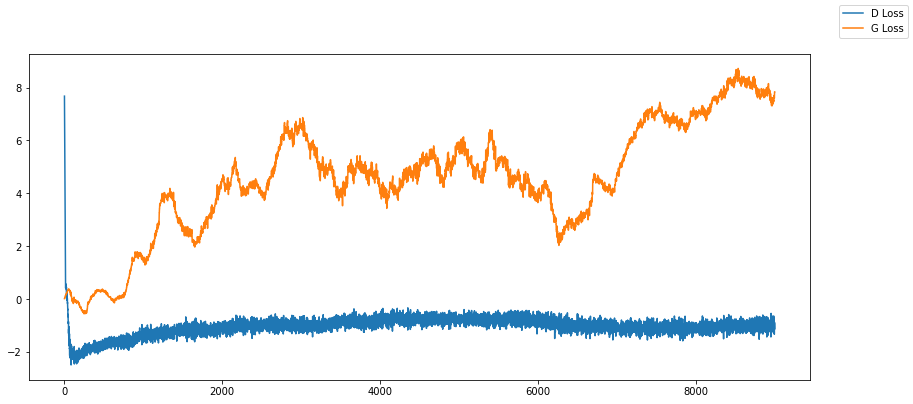

In [12]:
time_start = time.time()
epochs = 3000

for epoch in range(epochs):
    print()
    print(f'Epoca: {epoch}')
    training_loop(training_dataloader)
print(time.time() - time_start)
print("Done!!!")

trace_fig = plt.figure(figsize=(14,6))
trace_ax = plt.axes()
trace_ax.plot(d_losses, label='D Loss')
trace_ax.plot(g_losses, label='G Loss')

trace_fig.legend()

## Saving the Model

In [ ]:
#Saving discriminator
torch.save(discriminator.state_dict(),f'./models/discriminador_{cohort}.mdl')
#Saving Generator
torch.save(generator.state_dict(),f'./models/generator_{cohort}.mdl')